# PSA/VSA 경제성 최적화 노트북

이 노트북은 `model_shap.ipynb`의 surrogate 모델 구조와 `pas.py`의 전처리/물질수지 아이디어를 이용해서, 입력 가스 상태별 최적 운전조건을 찾기 위한 실행용 워크플로우입니다.

최적화 목적은 `CO2 1톤당 총비용 최소화`이며, 주요 조작변수는 다음 5개입니다.
- `tADS`
- `PL`
- `v0`
- `t_press`
- `t_depress`


In [4]:
# 기본 라이브러리와 최적화 모듈을 불러온다.
# 실행 위치가 루트이든 model 폴더이든 동작하도록 경로를 보정한다.

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
if (cwd / 'optimize_policy.py').exists():
    module_dir = cwd
elif (cwd / 'model' / 'optimize_policy.py').exists():
    module_dir = cwd / 'model'
else:
    raise FileNotFoundError('optimize_policy.py를 찾을 수 없습니다.')

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from optimize_policy import (
    PSAEconomicsOptimizer,
    CostConfig,
    ProcessConstants,
    GAS_STATE_COLS,
    load_training_data,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 1. 학습 데이터 로드 및 surrogate optimizer 초기화

여기서는 `model/output.csv`를 학습 데이터로 사용합니다. 이 파일에서 `status == 'ok'` 인 데이터만 사용해서 purity / recovery surrogate를 다시 학습합니다.

In [ ]:
# 현재 작업 경로에 따라 데이터 경로를 자동으로 맞춘다.

base_dir = module_dir
train_csv = r'C:\Users\junhyun111\Desktop\psa\mof\output.csv'

train_df = load_training_data(train_csv)
print(f'원본 학습 데이터 shape: {train_df.shape}')

# 공정 상수와 비용 가정은 dataclass로 분리되어 있다.
# 아래 숫자는 비교용 기본값이므로, 실제 사업 조건에 맞게 수정하면 된다.

process_constants = ProcessConstants(
    temperature_k=313.15,
    high_pressure_bar=1.2,
    bed_length_m=1.0,
    area_m2=0.01,
    bed_void_fraction=0.39,
    particle_diameter_m=1.2e-3,
    operating_hours_per_year=8000.0,
)

cost_config = CostConfig(
    electricity_cost_per_kwh=110.0,
    carbon_price_per_tco2=50000.0,
    co2_credit_per_tco2=0.0,
    annualized_capex_per_m3_bed=200000.0,
    annual_fixed_om_per_m3_bed=40000.0,
    annual_adsorbent_budget_per_m3_bed=80000.0,
    purity_target=0.90,
    recovery_target=0.90,
    purity_penalty_weight=200000.0,
    recovery_penalty_weight=250000.0,
    uncertainty_penalty_weight=50000.0,
)

optimizer = PSAEconomicsOptimizer(
    train_df=train_df,
    constants=process_constants,
    cost=cost_config,
)

print(f'유효 학습 데이터 shape: {optimizer.train_df.shape}')
optimizer.train_df.head()


원본 학습 데이터 shape: (195, 34)
유효 학습 데이터 shape: (195, 34)


,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,n2_mol_frac_effective,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery,sample_id,valid_physics,status_detail,n_cycles,status,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail
0,121.231639,0.242283,0.011761,64.864674,38.008555,27.906160,0.988694,7.974843,0.079348,0.183007,0.816986,0.840412,0.895745,0.945157,1.058946,0.522849,0.163898,0.637936,1,True,ok,10,ok,0.046904,0.209381,0.029921,0.152640,11.255814,0.149594,11.460740,0.799046,0.200954,0.204926,0.051537
1,163.806902,0.338393,0.028594,59.693324,65.954041,9.681633,0.884149,6.019091,0.087091,0.235562,0.764434,0.866624,0.913090,0.952002,1.056361,0.415982,0.490516,0.692717,2,True,ok,10,ok,0.198327,0.643589,0.137384,0.142697,7.030726,0.129357,7.147577,0.696158,0.303842,0.116850,0.051000
2,82.472037,0.230902,0.022071,50.168231,40.971812,43.930029,0.138311,2.153061,0.049224,0.197930,0.802061,0.894359,0.938445,0.968546,1.034702,0.355460,0.227966,0.690067,3,True,ok,10,ok,0.064763,0.262424,0.044691,0.151351,12.074274,0.146860,12.263334,0.789300,0.210700,0.189060,0.050469
3,96.366813,0.162668,0.021114,53.254276,26.810740,57.544259,0.723156,7.336068,0.048012,0.249925,0.750059,0.847753,0.901771,0.952673,1.045096,0.514483,0.317861,0.722666,4,True,ok,10,ok,0.091411,0.274318,0.066059,0.141765,14.988749,0.140240,15.151836,0.781032,0.218968,0.163086,0.045722
4,113.613987,0.180127,0.031534,20.341739,60.884987,44.615595,0.020142,9.788497,0.033695,0.215893,0.784096,0.883246,0.932161,0.973748,1.043018,0.407473,0.389094,0.708194,5,True,ok,10,ok,0.139038,0.504942,0.098466,0.154598,13.522129,0.147633,13.635937,0.700612,0.299388,0.113808,0.048633


## 2. 최적화 대상 입력 가스 상태 정의

아래 `gas_states_df`를 직접 수정해서 원하는 가스 상태 케이스를 넣으면 됩니다.

필수 컬럼:
- `co2_mol_frac`
- `h2o_ppmv`
- `sox_ppmv`
- `nox_ppmv`
- `dust_mg_Nm3`

In [10]:
# 예시 입력 가스 상태를 정의한다.
# 실제 분석 시 이 표를 원하는 케이스로 바꾸면 된다.

gas_states_df = pd.DataFrame([
    {
        'co2_mol_frac': 0.18,
        'h2o_ppmv': 10.0,
        'sox_ppmv': 0.20,
        'nox_ppmv': 3.0,
        'dust_mg_Nm3': 0.02,
    },
    {
        'co2_mol_frac': 0.22,
        'h2o_ppmv': 20.0,
        'sox_ppmv': 0.10,
        'nox_ppmv': 2.0,
        'dust_mg_Nm3': 0.01,
    },
])

# 컬럼 누락 여부를 확인한다.
missing_cols = [col for col in GAS_STATE_COLS if col not in gas_states_df.columns]
if missing_cols:
    raise ValueError(f'가스 상태 컬럼 누락: {missing_cols}')

gas_states_df


,co2_mol_frac,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3
0,0.18,10.0,0.2,3.0,0.02
1,0.22,20.0,0.1,2.0,0.01


## 3. 최적화 실행

전역 탐색은 LHS 기반으로 하고, 이후 상위 해 주변에서 국소 탐색을 반복합니다.

주요 파라미터:
- `n_samples`: 초기 후보 수
- `local_steps`: 국소 탐색 반복 횟수
- `elite_size`: 각 단계에서 확장할 상위 해 개수

정확도를 높이려면 `n_samples`를 올리면 되지만 계산 시간도 함께 증가합니다.

In [11]:
# 최적화 탐색 파라미터를 설정한다.
# 빠른 테스트는 작게, 실제 분석은 더 크게 잡는 것이 좋다.

n_samples = 4000
local_steps = 6
elite_size = 12
seed = 42

summary_rows = []
candidate_frames = []

for gas_state_id, gas_state in gas_states_df.iterrows():
    print(f'[최적화 시작] gas_state_id={gas_state_id + 1}')

    best, evaluated = optimizer.optimize_for_gas_state(
        gas_state=gas_state.to_dict(),
        n_samples=n_samples,
        local_steps=local_steps,
        elite_size=elite_size,
        seed=seed + gas_state_id,
    )

    # 요약 행은 상태별 최적점만 저장한다.
    summary_rows.append({
        'gas_state_id': gas_state_id + 1,
        **gas_state.to_dict(),
        'opt_tADS': best['tADS'],
        'opt_PL': best['PL'],
        'opt_v0': best['v0'],
        'opt_t_press': best['t_press'],
        'opt_t_depress': best['t_depress'],
        'pred_CO2_purity': best['pred_CO2_purity'],
        'pred_CO2_recovery': best['pred_CO2_recovery'],
        'specific_energy_kwh_per_tco2': best['specific_energy_kwh_per_tco2'],
        'energy_cost_per_tco2': best['energy_cost_per_tco2'],
        'capex_proxy_cost_per_tco2': best['capex_proxy_cost_per_tco2'],
        'adsorbent_cost_per_tco2': best['adsorbent_cost_per_tco2'],
        'unrecovered_cost_per_tco2': best['unrecovered_cost_per_tco2'],
        'purity_penalty_per_tco2': best['purity_penalty_per_tco2'],
        'recovery_penalty_per_tco2': best['recovery_penalty_per_tco2'],
        'uncertainty_penalty_per_tco2': best['uncertainty_penalty_per_tco2'],
        'domain_penalty_per_tco2': best['domain_penalty_per_tco2'],
        'total_cost_per_tco2': best['total_cost_per_tco2'],
    })

    # 전체 후보 테이블은 사후 분석용으로 저장한다.
    evaluated = evaluated.copy()
    evaluated.insert(0, 'gas_state_id', gas_state_id + 1)
    for col in GAS_STATE_COLS:
        evaluated[col] = gas_state[col]
    candidate_frames.append(evaluated)

summary_df = pd.DataFrame(summary_rows)
all_candidates_df = pd.concat(candidate_frames, ignore_index=True)

summary_df


[최적화 시작] gas_state_id=1
[최적화 시작] gas_state_id=2


,gas_state_id,co2_mol_frac,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,opt_tADS,opt_PL,opt_v0,opt_t_press,opt_t_depress,pred_CO2_purity,pred_CO2_recovery,specific_energy_kwh_per_tco2,energy_cost_per_tco2,capex_proxy_cost_per_tco2,adsorbent_cost_per_tco2,unrecovered_cost_per_tco2,purity_penalty_per_tco2,recovery_penalty_per_tco2,uncertainty_penalty_per_tco2,domain_penalty_per_tco2,total_cost_per_tco2
0,1,0.18,10.0,0.2,3.0,0.02,174.792645,0.312212,0.031686,62.616545,32.846333,0.371125,0.664231,591.554567,65071.002330,5668.295701,1535.895090,25275.025858,55941.787672,13896.764268,3289.091601,0.000000,171811.521659
1,2,0.22,20.0,0.1,2.0,0.01,177.426583,0.350000,0.031625,54.441881,47.022887,0.396943,0.717176,543.545927,59790.051933,4348.732602,1221.396077,19717.877530,50613.307430,8356.138712,3020.516817,32.137138,147969.904759


## 4. 결과 저장

요약 결과와 모든 후보 결과를 CSV로 저장합니다.

In [12]:
# 결과 파일을 model 폴더 안에 저장한다.

summary_output_path = base_dir / 'optimization_results.csv'
candidates_output_path = base_dir / 'optimization_candidates.csv'

summary_df.to_csv(summary_output_path, index=False)
all_candidates_df.to_csv(candidates_output_path, index=False)

print(f'저장 완료: {summary_output_path}')
print(f'저장 완료: {candidates_output_path}')


저장 완료: c:\Users\junhyun111\Desktop\mf\optimization\optimization_results.csv
저장 완료: c:\Users\junhyun111\Desktop\mf\optimization\optimization_candidates.csv


## 5. 상태별 최적 운전조건 확인

In [13]:
# 상태별 최적 운전조건과 비용을 보기 좋게 정리한다.

display_cols = [
    'gas_state_id',
    'co2_mol_frac', 'h2o_ppmv', 'sox_ppmv', 'nox_ppmv', 'dust_mg_Nm3',
    'opt_tADS', 'opt_PL', 'opt_v0', 'opt_t_press', 'opt_t_depress',
    'pred_CO2_purity', 'pred_CO2_recovery',
    'specific_energy_kwh_per_tco2', 'total_cost_per_tco2',
]

summary_df[display_cols].sort_values('total_cost_per_tco2')


,gas_state_id,co2_mol_frac,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,opt_tADS,opt_PL,opt_v0,opt_t_press,opt_t_depress,pred_CO2_purity,pred_CO2_recovery,specific_energy_kwh_per_tco2,total_cost_per_tco2
1,2,0.22,20.0,0.1,2.0,0.01,177.426583,0.350000,0.031625,54.441881,47.022887,0.396943,0.717176,543.545927,147969.904759
0,1,0.18,10.0,0.2,3.0,0.02,174.792645,0.312212,0.031686,62.616545,32.846333,0.371125,0.664231,591.554567,171811.521659


## 6. 비용 항목 분해 시각화

어떤 비용 항목이 총비용을 지배하는지 상태별로 확인합니다.

C:\Users\junhyun111\AppData\Local\Temp\ipykernel_18404\3686633486.py:27: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junhyun111\AppData\Local\Temp\ipykernel_18404\3686633486.py:27: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junhyun111\AppData\Local\Temp\ipykernel_18404\3686633486.py:27: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junhyun111\AppData\Local\Temp\ipykernel_18404\3686633486.py:27: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junhyun111\AppData\Local\Temp\ipykernel_18404\3686633486.py:27: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\junhyun111\AppData\Local\Temp\ipykernel_18404\3686633486.py:27: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missin

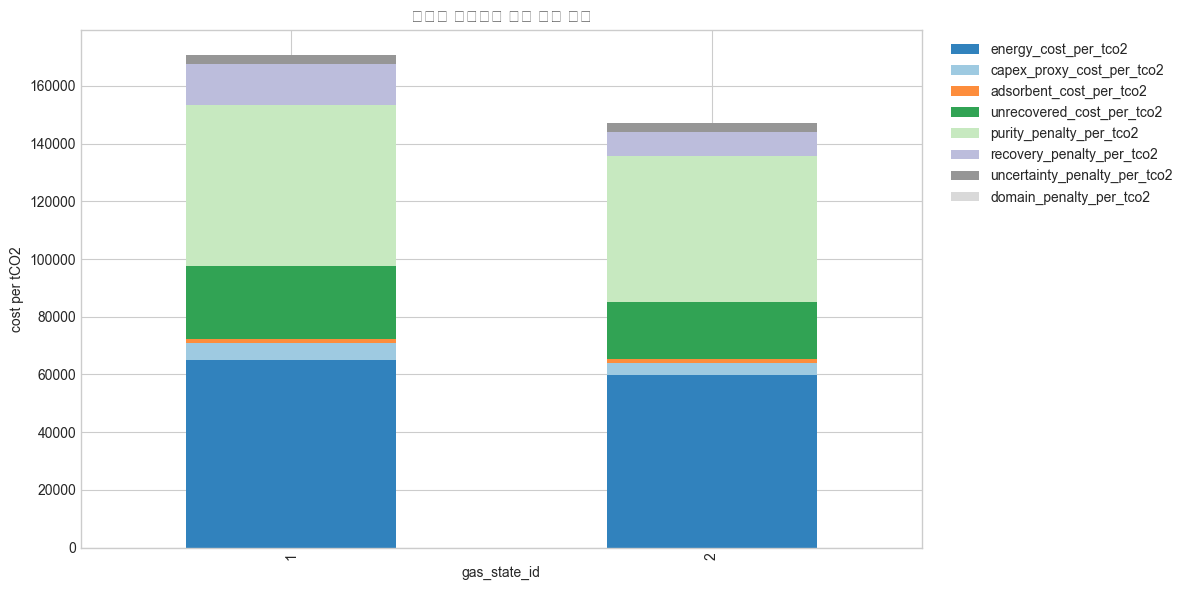

In [14]:
# 주요 비용 항목만 골라서 stacked bar chart를 그린다.

cost_cols = [
    'energy_cost_per_tco2',
    'capex_proxy_cost_per_tco2',
    'adsorbent_cost_per_tco2',
    'unrecovered_cost_per_tco2',
    'purity_penalty_per_tco2',
    'recovery_penalty_per_tco2',
    'uncertainty_penalty_per_tco2',
    'domain_penalty_per_tco2',
]

plot_df = summary_df[['gas_state_id'] + cost_cols].copy()
plot_df = plot_df.set_index('gas_state_id')

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20c',
)
ax.set_title('상태별 최적점의 비용 항목 분해')
ax.set_xlabel('gas_state_id')
ax.set_ylabel('cost per tCO2')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


## 7. 특정 가스 상태의 후보 해 탐색 결과 보기

아래 셀에서 `selected_gas_state_id`를 바꾸면, 해당 가스 상태에서 어떤 조건들이 낮은 비용을 보였는지 확인할 수 있습니다.

In [15]:
# 특정 가스 상태에 대해 상위 후보들을 정렬해서 본다.

selected_gas_state_id = 1

candidate_view_cols = [
    'gas_state_id',
    'tADS', 'PL', 'v0', 't_press', 't_depress',
    'pred_CO2_purity', 'pred_CO2_recovery',
    'specific_energy_kwh_per_tco2',
    'energy_cost_per_tco2',
    'capex_proxy_cost_per_tco2',
    'adsorbent_cost_per_tco2',
    'unrecovered_cost_per_tco2',
    'total_cost_per_tco2',
]

all_candidates_df.loc[
    all_candidates_df['gas_state_id'].eq(selected_gas_state_id),
    candidate_view_cols,
].sort_values('total_cost_per_tco2').head(20)


,gas_state_id,tADS,PL,v0,t_press,t_depress,pred_CO2_purity,pred_CO2_recovery,specific_energy_kwh_per_tco2,energy_cost_per_tco2,capex_proxy_cost_per_tco2,adsorbent_cost_per_tco2,unrecovered_cost_per_tco2,total_cost_per_tco2
0,1,174.792645,0.312212,0.031686,62.616545,32.846333,0.371125,0.664231,591.554567,65071.002330,5668.295701,1535.895090,25275.025858,171811.521659
1,1,172.835902,0.309809,0.031442,60.257537,33.451556,0.371031,0.664734,592.390967,65163.006405,5698.596428,1544.105448,25218.064629,171847.557444
2,1,175.945759,0.312133,0.031572,60.452016,33.260263,0.370879,0.664403,591.966790,65116.346894,5655.825029,1532.516006,25255.566397,171854.610123
3,1,180.000000,0.310497,0.031457,58.627631,30.159684,0.370476,0.664755,593.077666,65238.543261,5581.674627,1512.424034,25215.625331,171854.903321
4,1,172.606116,0.310136,0.031658,57.350518,33.586393,0.370638,0.664799,592.927674,65222.044174,5623.683019,1523.806730,25210.664938,171859.769158
5,1,178.060778,0.312052,0.031386,60.339544,33.219618,0.370879,0.664403,591.986456,65118.510196,5672.554017,1537.048933,25255.566397,171881.381137
6,1,175.697462,0.316105,0.031719,57.967044,31.819894,0.371167,0.663161,590.382328,64942.056026,5590.027881,1514.687452,25396.449222,171882.134169
7,1,180.000000,0.310323,0.031697,56.602050,33.082870,0.370259,0.664830,593.480998,65282.909827,5550.352229,1503.936842,25207.196282,171884.211279
8,1,176.590458,0.317715,0.031158,58.807523,32.860469,0.372129,0.662379,588.396607,64723.626782,5716.473094,1548.949352,25485.541545,171891.212376
9,1,175.982200,0.311747,0.031587,58.590675,32.658535,0.370616,0.664424,592.496748,65174.642302,5620.054770,1522.823611,25253.124666,171900.052235
